# Module 6 — Multi-Panel Figures

This module is the matplotlib equivalent of `facet_wrap()` and `facet_grid()` in ggplot2, except matplotlib does not auto-facet. You decide the grid, then populate each cell.

More work, more control.

The mental model:

```text
┌──────────────────────────────────────────────────────────┐
│ A Figure can hold many Axes objects in a layout.         │
│ You choose the layout, then draw on each Axes one at     │
│ a time. Each Axes is independent: its own data, title,   │
│ ticks, colors, and annotations.                          │
└──────────────────────────────────────────────────────────┘
```

Matplotlib gives several ways to lay out multiple panels, in increasing order of flexibility:

1. `plt.subplots(nrows, ncols)` — regular grid; useful for most cases
2. `subplot_mosaic("AB;CC")` — named, irregular grid; modern favorite
3. `GridSpec` — full control over rows, columns, and spans
4. `fig.add_axes([x, y, w, h])` — place an `Axes` at exact coordinates

Start with `plt.subplots()`. Use `subplot_mosaic()` when the layout becomes irregular. Learn `GridSpec` when `subplot_mosaic()` is not enough. Use `fig.add_axes()` mostly for inset plots.

## 1. `plt.subplots()` for regular grids

The common pattern is to create a `Figure` plus an array of `Axes` objects.

(2, 3)


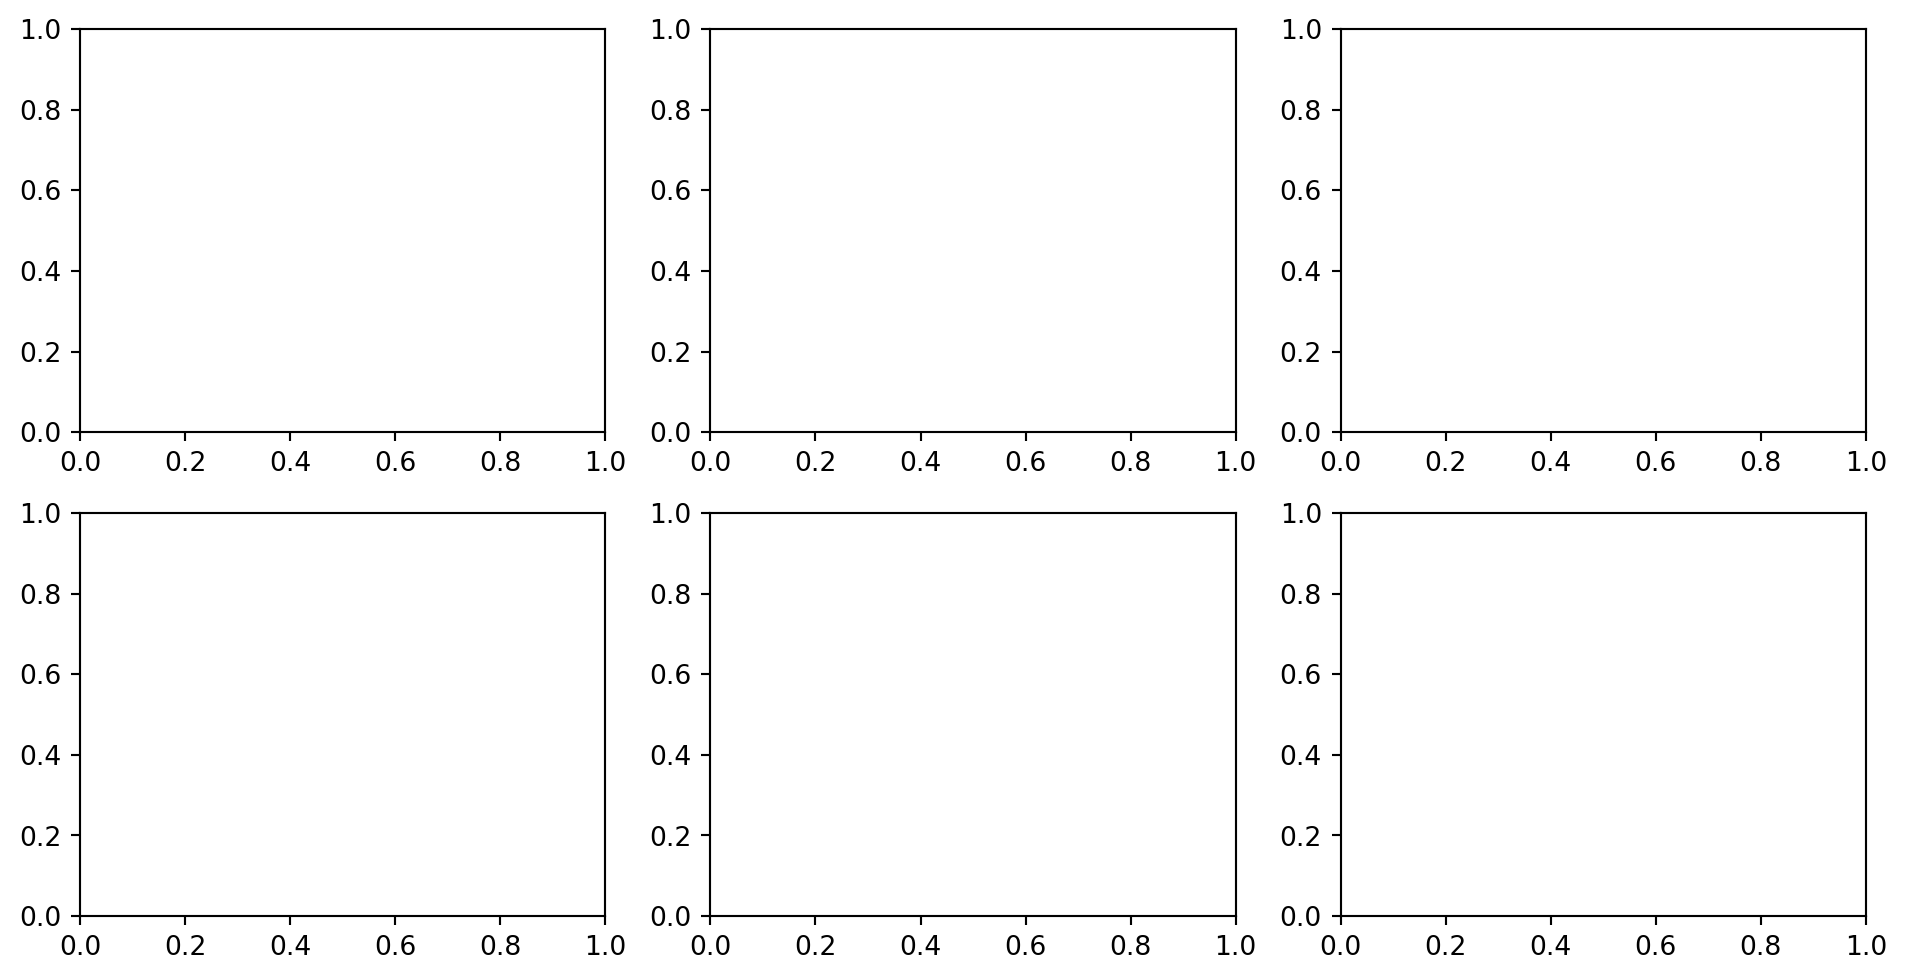

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
print(axes.shape)
plt.show()

For `plt.subplots(2, 3)`, `axes` is a 2D NumPy array of `Axes` objects with shape `(2, 3)`. Individual panels are accessed by indexing.

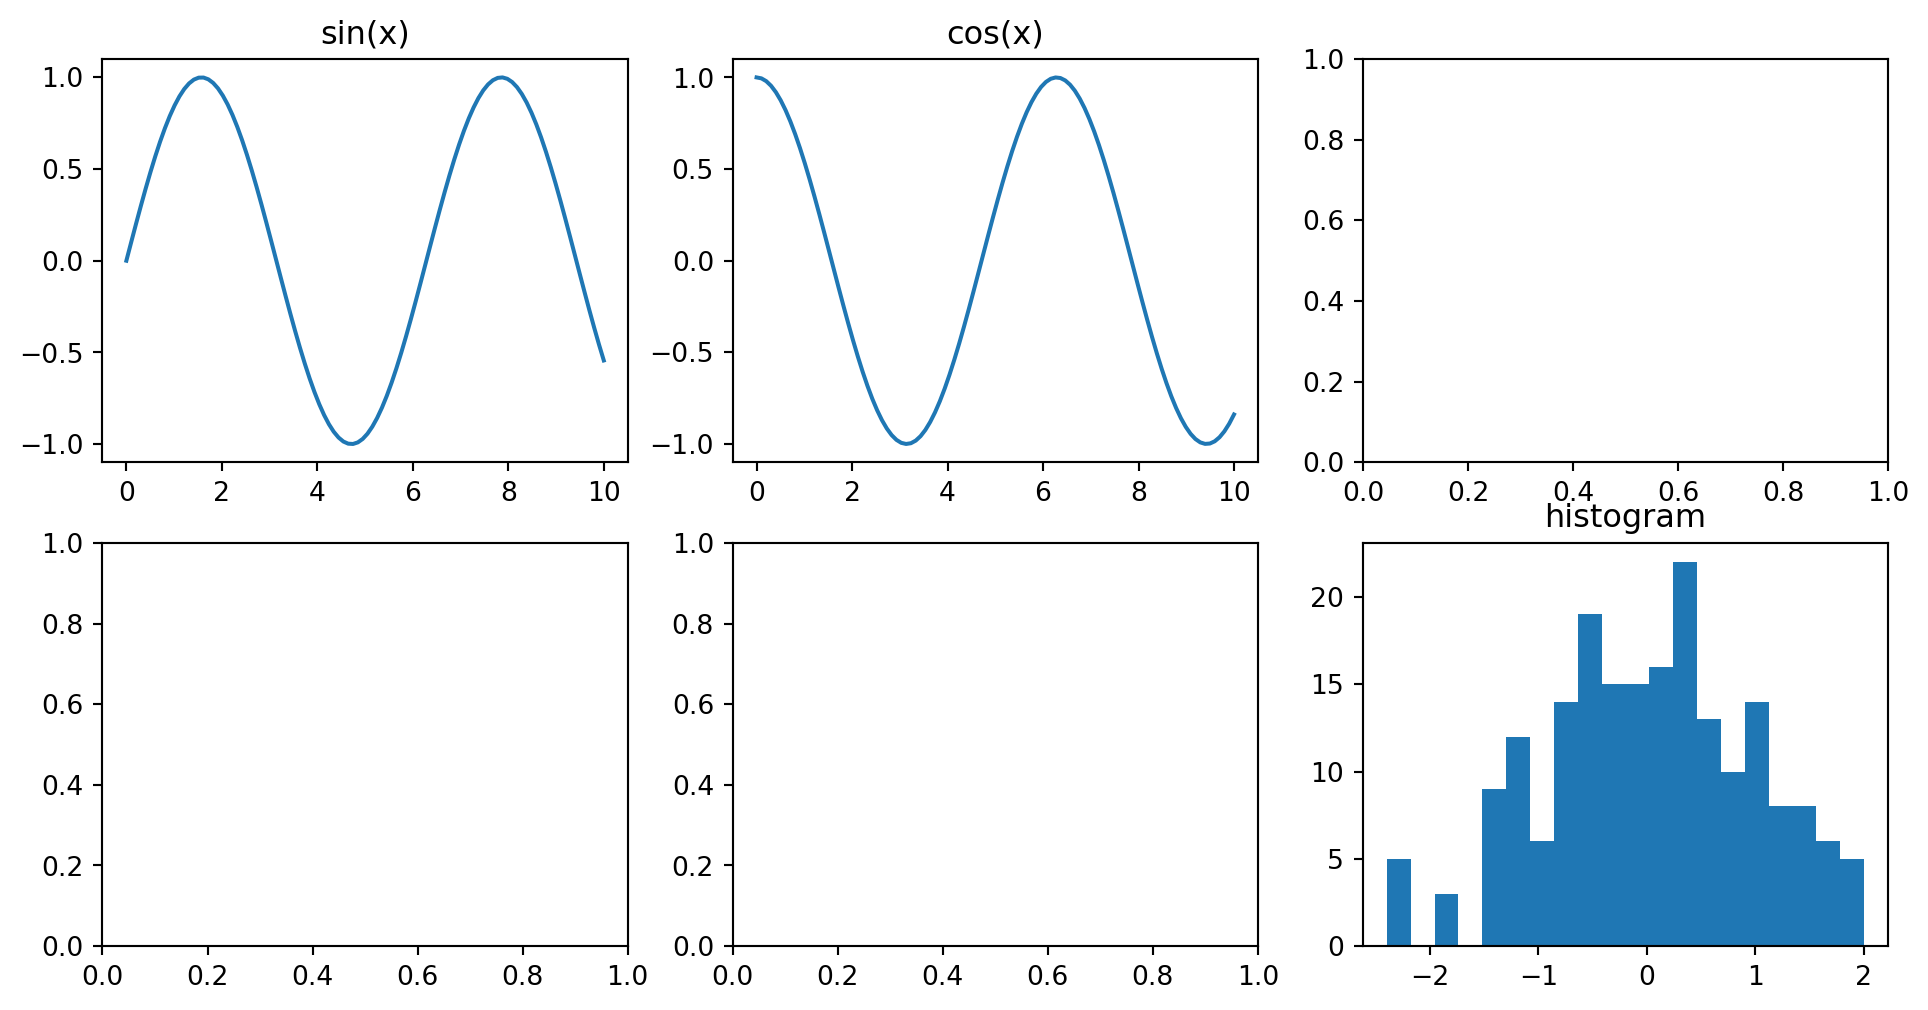

In [2]:
x = np.linspace(0, 10, 100)
rng = np.random.default_rng(0)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

axes[0, 0].plot(x, np.sin(x))
axes[0, 0].set_title("sin(x)")

axes[0, 1].plot(x, np.cos(x))
axes[0, 1].set_title("cos(x)")

axes[1, 2].hist(rng.normal(size=200), bins=20)
axes[1, 2].set_title("histogram")

plt.show()

The shape of `axes` for `plt.subplots(2, 3)`:

```text
                  col 0        col 1        col 2
              ┌─────────┐  ┌─────────┐  ┌─────────┐
row 0         │axes[0,0]│  │axes[0,1]│  │axes[0,2]│
              └─────────┘  └─────────┘  └─────────┘
              ┌─────────┐  ┌─────────┐  ┌─────────┐
row 1         │axes[1,0]│  │axes[1,1]│  │axes[1,2]│
              └─────────┘  └─────────┘  └─────────┘
```

### The single-row / single-column gotcha

When `nrows=1` or `ncols=1`, the returned `axes` object may not be 2D.

```python
fig, axes = plt.subplots(1, 3)  # shape (3,), a 1D array
axes[0].plot(...)              # works
axes[0, 0].plot(...)           # IndexError

fig, axes = plt.subplots(1, 1)  # a single Axes, not an array
axes.plot(...)                  # works
axes[0].plot(...)               # TypeError
```

Two ways to avoid thinking about this too much:

```python
# Option A: always return a 2D array
fig, axes = plt.subplots(1, 3, squeeze=False)  # shape (1, 3)

# Option B: flatten and iterate
fig, axes = plt.subplots(2, 3)
for ax in axes.flat:
    ax.set_xlabel("x")
```

`axes.flat` gives a 1D iterator over all panels, regardless of grid shape. It is very useful for loop-driven plotting.

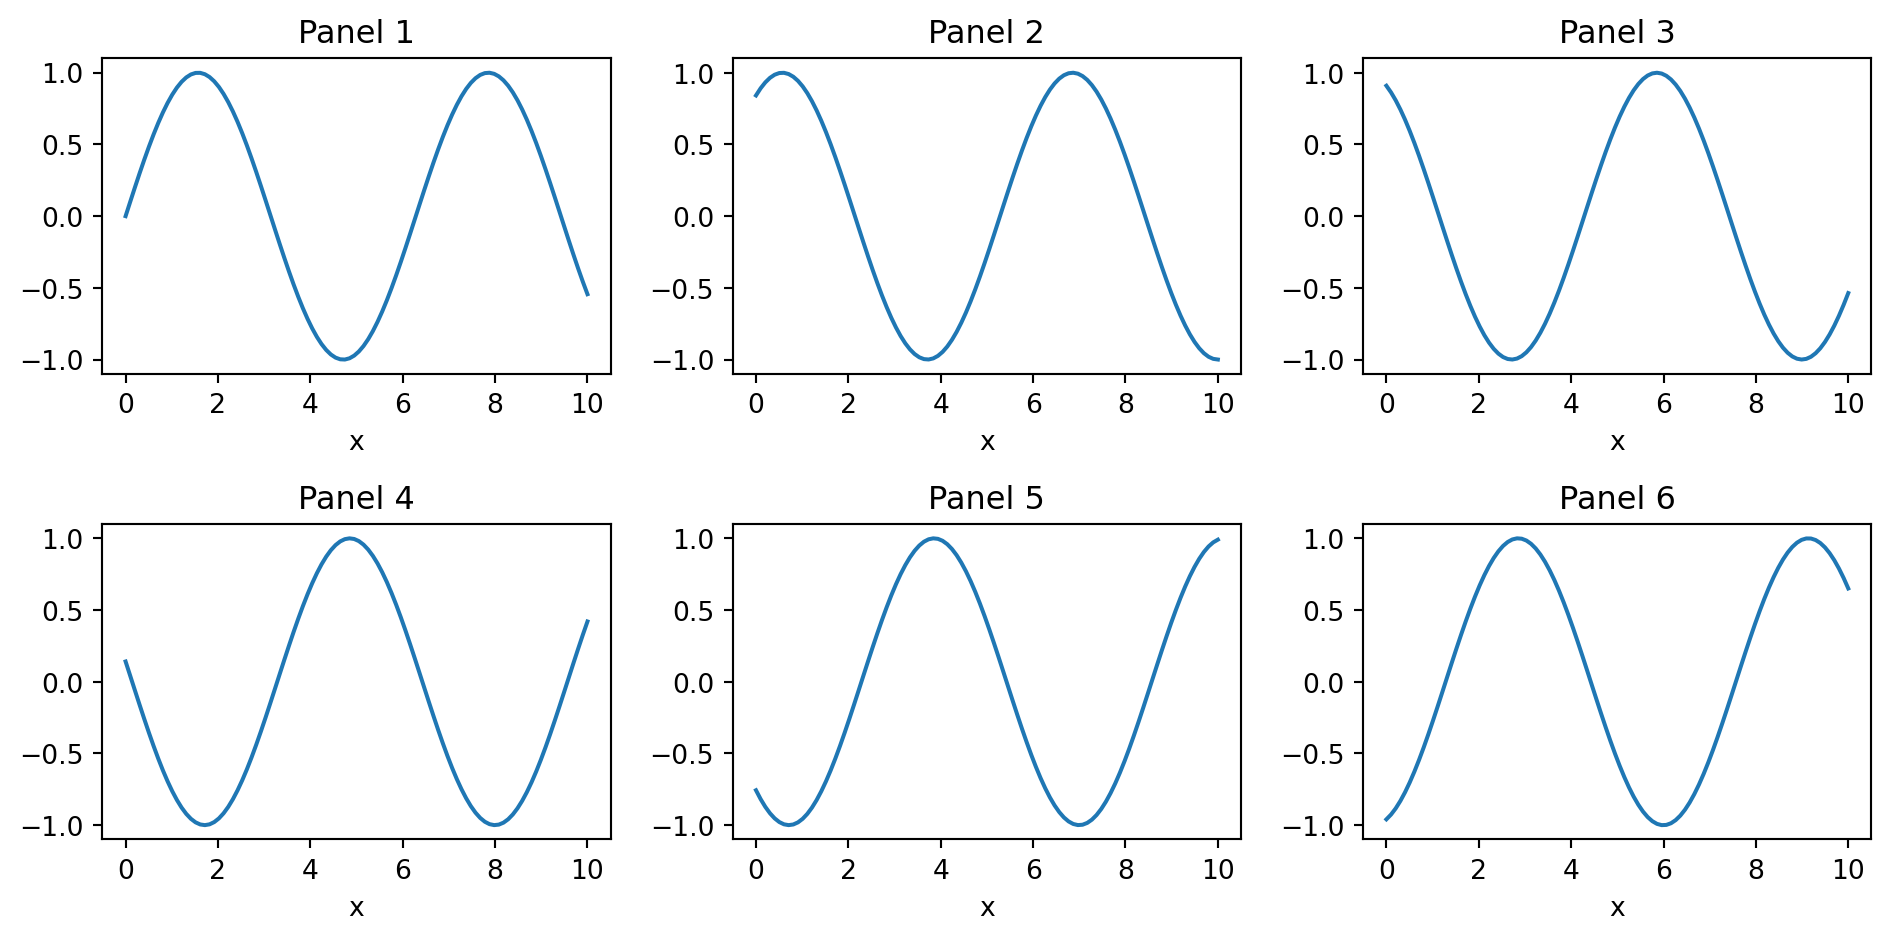

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.plot(x, np.sin(x + i))
    ax.set_title(f"Panel {i + 1}")
    ax.set_xlabel("x")

fig.tight_layout()
plt.show()

### Looping over data and panels together

Faceted plotting in matplotlib is usually a `for` loop.

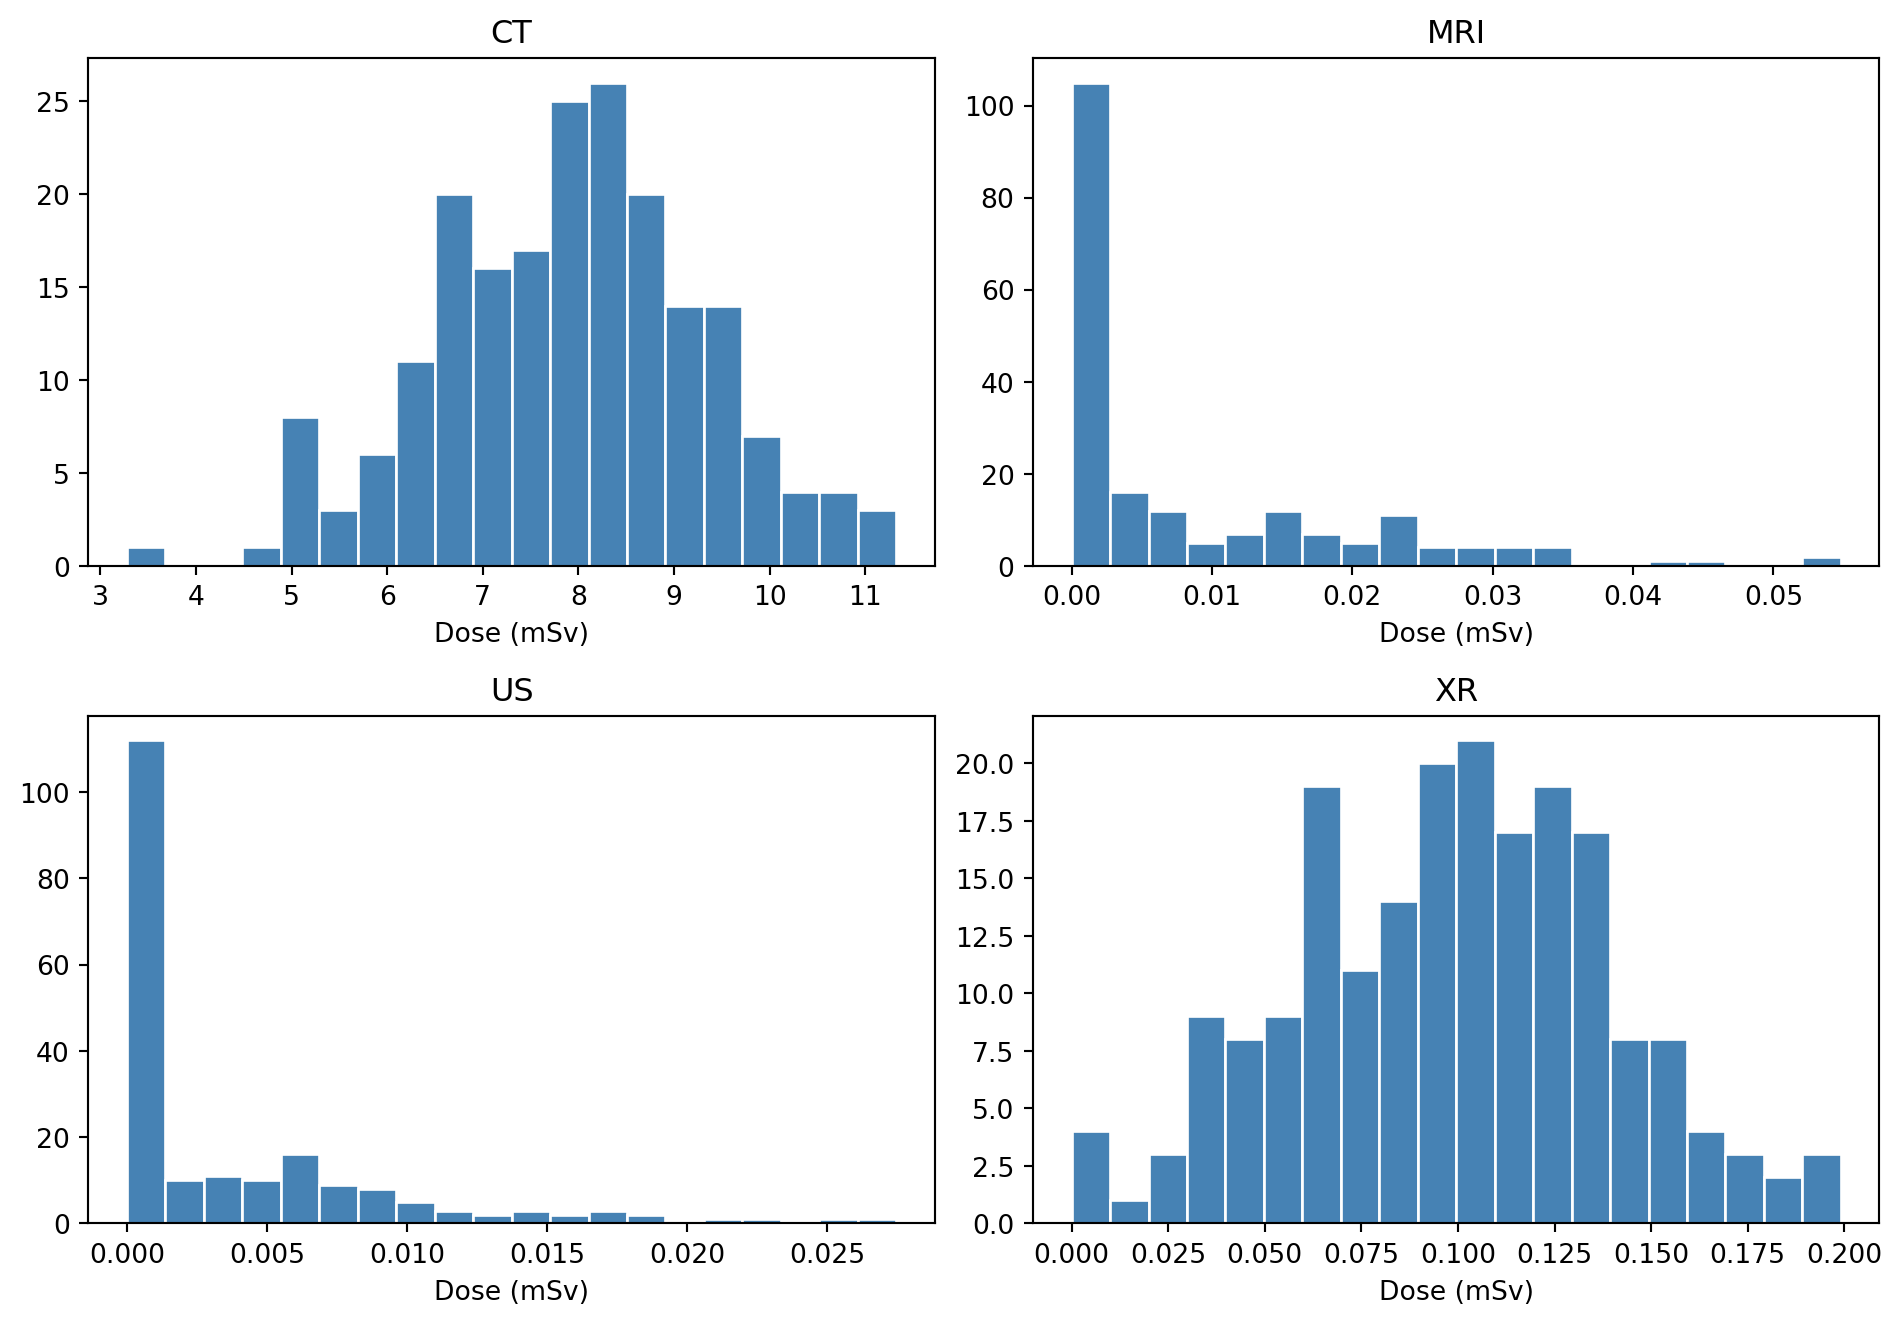

In [4]:
def simulate_dose_data(modality, n=200, seed=0):
    rng = np.random.default_rng(seed + hash(modality) % 1000)
    params = {
        "CT": (8.0, 1.5),
        "MRI": (0.0, 0.02),
        "US": (0.0, 0.01),
        "XR": (0.10, 0.04),
    }
    mean, sd = params[modality]
    return np.clip(rng.normal(mean, sd, n), 0, None)

modalities = ["CT", "MRI", "US", "XR"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, modality in zip(axes.flat, modalities):
    data = simulate_dose_data(modality)
    ax.hist(data, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(modality)
    ax.set_xlabel("Dose (mSv)")

fig.tight_layout()
plt.show()

This is the matplotlib equivalent of `facet_wrap(~ modality)`. It is verbose, but it gives full control over each panel. If one modality needs a different x-range or annotation, use a normal `if` block inside the loop.

## 2. Shared axes: `sharex` and `sharey`

When panels show the same kind of data, shared scales make comparison easier.

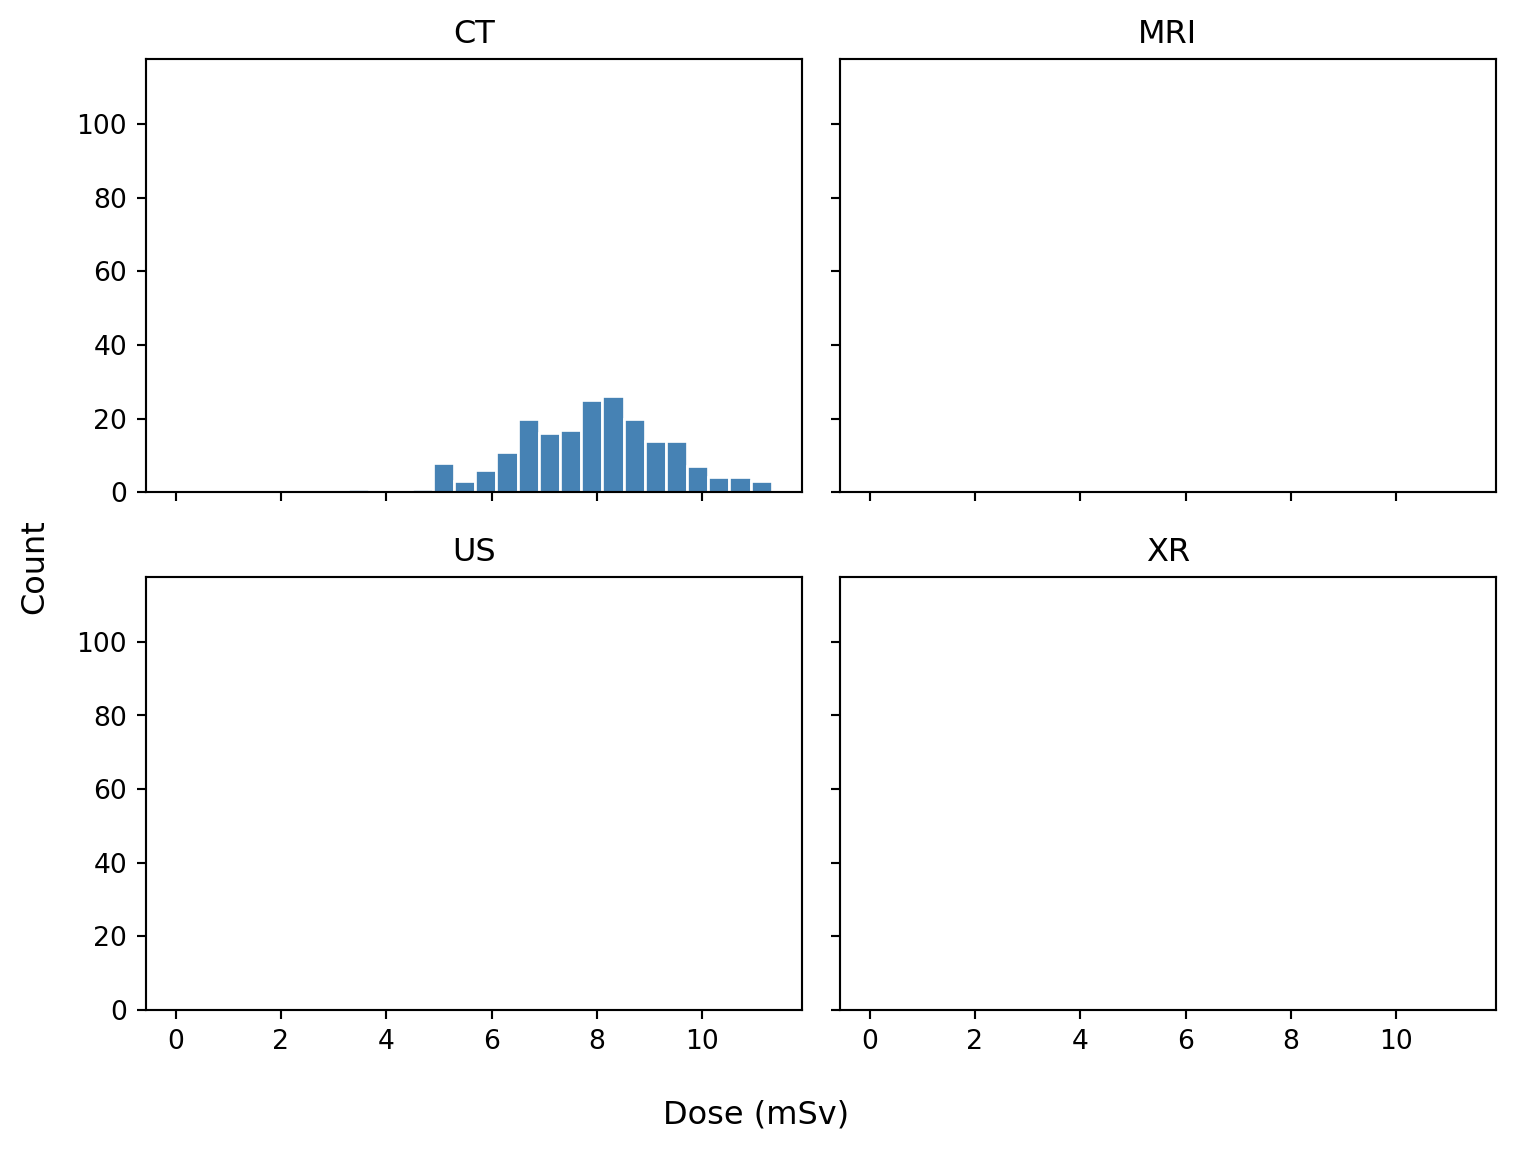

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 6),
    sharex=True,
    sharey=True,
)

for ax, modality in zip(axes.flat, modalities):
    data = simulate_dose_data(modality)
    ax.hist(data, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(modality)

fig.supxlabel("Dose (mSv)")
fig.supylabel("Count")
fig.tight_layout()
plt.show()

With `sharex=True`, all panels use the same x-range, and matplotlib automatically hides repeated x tick labels except on the bottom row. `sharey=True` does the same for the y-axis.

Shared axes are useful when the reader should compare panels directly. Avoid sharing axes when panels genuinely need different scales to reveal different structures.

## Key takeaways

- A multi-panel figure is one `Figure` containing multiple `Axes` objects.
- `plt.subplots()` is the default tool for regular grids.
- The returned `axes` object changes shape depending on `nrows`, `ncols`, and `squeeze`.
- `axes.flat` is the practical way to loop over panels.
- Faceting in matplotlib is a loop over axes and data groups.
- Use `sharex` and `sharey` when panels should be visually comparable.